1.30 : Patient-1 Arrived
2.29 : Patient-2 Arrived
4.46 : Patient-3 Arrived
7.19 : Patient-4 Arrived
10.43 : Patient-5 Arrived
13.73 : Patient-2 Discharged
15.74 : Patient-1 Discharged
16.04 : Patient-6 Arrived
16.98 : Patient-7 Arrived
19.98 : Patient-8 Arrived
30.33 : Patient-3 Discharged
31.13 : Patient-4 Discharged
36.03 : Patient-6 Discharged
36.94 : Patient-9 Arrived
37.75 : Patient-7 Discharged
37.83 : Patient-10 Arrived
38.06 : Patient-11 Arrived
38.56 : Patient-12 Arrived
38.71 : Patient-13 Arrived
40.52 : Patient-8 Discharged
52.20 : Patient-14 Arrived
52.33 : Patient-9 Discharged
58.41 : Patient-10 Discharged
61.02 : Patient-15 Arrived
61.55 : Patient-16 Arrived
61.73 : Patient-17 Arrived
62.97 : Patient-18 Arrived
72.23 : Patient-11 Discharged
76.73 : Patient-19 Arrived
80.06 : Patient-5 Discharged
81.09 : Patient-20 Arrived
86.45 : Patient-12 Discharged
87.20 : Patient-21 Arrived
94.34 : Patient-22 Arrived
95.36 : Patient-13 Discharged
103.35 : Patient-23 Arrived
113.46 : P

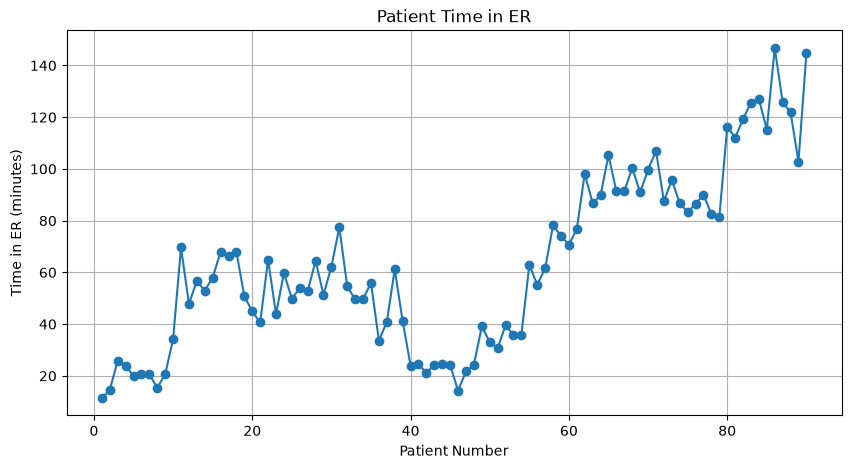

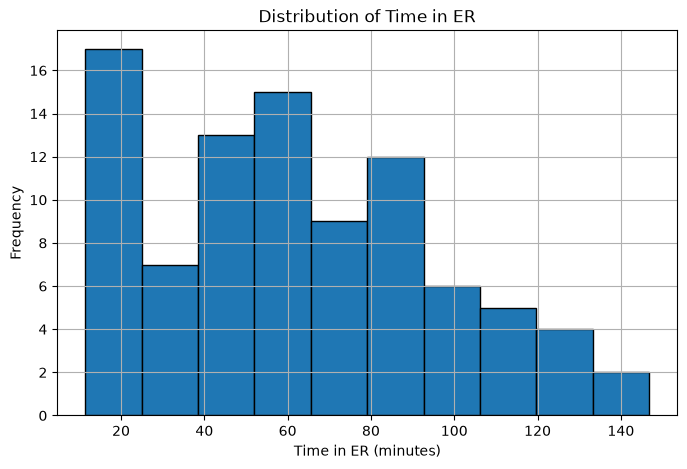

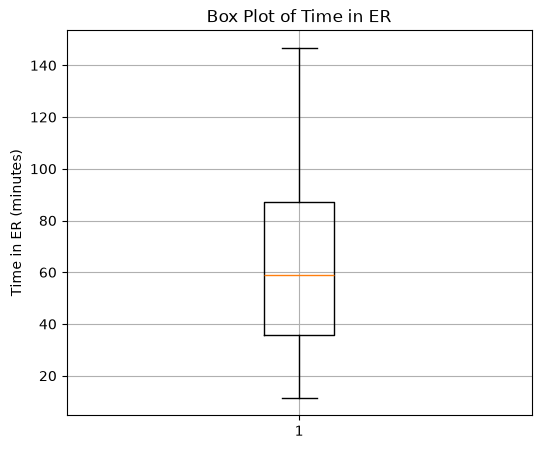

In [5]:
import simpy
import random
import matplotlib.pyplot as plt

# -----------------------------
# Parameters
# -----------------------------
SIM_TIME = 500

MEAN_INTERARRIVAL = 5
MEAN_TRIAGE = 4
MEAN_TREATMENT = 10
MEAN_DISCHARGE = 2

# -----------------------------
# Statistics
# -----------------------------
waiting_times = []

# -----------------------------
# Patient Process
# -----------------------------
def patient(env, name, triage, doctor, discharge):

    arrival_time = env.now

    print(f"{env.now:.2f} : {name} Arrived")

    # -----------------------------
    # Triage
    # -----------------------------
    with triage.request() as req:
        yield req
        yield env.timeout(random.expovariate(1 / MEAN_TRIAGE))

    # -----------------------------
    # Treatment
    # -----------------------------
    with doctor.request() as req:
        yield req
        yield env.timeout(random.expovariate(1 / MEAN_TREATMENT))

    # -----------------------------
    # Discharge
    # -----------------------------
    with discharge.request() as req:
        yield req
        yield env.timeout(random.expovariate(1 / MEAN_DISCHARGE))

    total_time = env.now - arrival_time

    waiting_times.append(total_time)

    print(f"{env.now:.2f} : {name} Discharged")

# -----------------------------
# Arrival Process
# -----------------------------
def arrivals(env, triage, doctor, discharge):

    patient_id = 1

    while True:

        interarrival = random.expovariate(1 / MEAN_INTERARRIVAL)

        yield env.timeout(interarrival)

        env.process(
            patient(
                env,
                f"Patient-{patient_id}",
                triage,
                doctor,
                discharge,
            )
        )

        patient_id += 1

# -----------------------------
# Environment
# -----------------------------
env = simpy.Environment()

triage = simpy.Resource(env, capacity=1)

doctor = simpy.Resource(env, capacity=2)

discharge = simpy.Resource(env, capacity=1)

env.process(arrivals(env, triage, doctor, discharge))

env.run(until=SIM_TIME)

# -----------------------------
# Results
# -----------------------------
print("\n========== RESULTS ==========")

print("Patients Completed =", len(waiting_times))

print("Average Time in ER =", round(sum(waiting_times) / len(waiting_times), 2), "minutes")

print("Maximum Time in ER =", round(max(waiting_times), 2), "minutes")

# ====================================================
# Plot 1 : Line Plot
# ====================================================

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(waiting_times)+1),
    waiting_times,
    marker='o'
)

plt.title("Patient Time in ER")

plt.xlabel("Patient Number")

plt.ylabel("Time in ER (minutes)")

plt.grid(True)

plt.show()

# ====================================================
# Plot 2 : Histogram
# ====================================================

plt.figure(figsize=(8,5))

plt.hist(
    waiting_times,
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Time in ER")

plt.xlabel("Time in ER (minutes)")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# ====================================================
# Plot 3 : Box Plot
# ====================================================

plt.figure(figsize=(6,5))

plt.boxplot(waiting_times)

plt.title("Box Plot of Time in ER")

plt.ylabel("Time in ER (minutes)")

plt.grid(True)

plt.show()

In [3]:
pip install simpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
